In [1]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/datos_procesados/consumo_010924_010625.csv')
df.head()

,lv_cons_id_cons,ano,mes,consumo,producto,fecha,localidad,barrio,tipo_producto,categoria,subcategoria
0,1,2024,9,0,2,2024-09-01,76001.0,102.0,6140.0,1.0,1.0
1,902353,2024,10,340,2,2024-10-01,76001.0,102.0,6140.0,1.0,1.0
2,1804705,2024,11,0,2,2024-11-01,76001.0,102.0,6140.0,1.0,1.0
3,2707057,2024,12,0,2,2024-12-01,76001.0,102.0,6140.0,1.0,1.0
4,3609409,2025,1,0,2,2025-01-01,76001.0,102.0,6140.0,1.0,1.0


In [3]:
df.fecha = pd.to_datetime(df.fecha)
df.fecha.describe()

count                          9031695
mean     2025-01-15 15:00:04.970894592
min                2024-09-01 00:00:00
25%                2024-11-01 00:00:00
50%                2025-02-01 00:00:00
75%                2025-04-01 00:00:00
max                2025-06-01 00:00:00
Name: fecha, dtype: object

In [4]:
PATH ='/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/CONSUMOS 2024/'
temp = pd.read_csv(PATH + 'CONSUMOS_01.txt', encoding='latin-1', sep='\t')

/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_22174/3872034539.py:2: DtypeWarning: Columns (31,36,37,39,43,44,49,50,53,54,66,67,70,71,72,73,74,75,79,83,85,86,88,91,93,97,98,101,111,112,113,114,119) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(PATH + 'CONSUMOS_01.txt', encoding='latin-1', sep='\t')


In [5]:
temp.shape

(765422, 128)

In [6]:
caracteristicas = df[['producto', 'localidad', 'barrio', 'tipo_producto', 'categoria', 'subcategoria']].drop_duplicates().copy()

In [7]:
new_con = temp[['MES_CONSUMO', 'CUCONUSE', 'CONSUMO_TOTAL']].copy()


In [8]:
new_con.MES_CONSUMO = pd.to_datetime(new_con.MES_CONSUMO, format='%Y%m')
new_con['mes'] = new_con.MES_CONSUMO.dt.month
new_con['ano'] = new_con.MES_CONSUMO.dt.year

In [9]:
new_con.MES_CONSUMO.describe()

count                           765422
mean     2023-11-29 18:07:39.134960896
min                2023-11-01 00:00:00
25%                2023-12-01 00:00:00
50%                2023-12-01 00:00:00
75%                2023-12-01 00:00:00
max                2023-12-01 00:00:00
Name: MES_CONSUMO, dtype: object

In [10]:
for i in ['02', '03', '04', '05', '06', '07', '08', '09', '10', '11']:
    temp = pd.read_csv(PATH + f'CONSUMOS_{i}.txt', encoding='latin-1', sep='\t')
    temp_con = temp[['MES_CONSUMO', 'CUCONUSE', 'CONSUMO_TOTAL']].copy()
    temp_con.MES_CONSUMO = pd.to_datetime(temp_con.MES_CONSUMO, format='%Y%m')
    temp_con['mes'] = temp_con.MES_CONSUMO.dt.month
    temp_con['ano'] = temp_con.MES_CONSUMO.dt.year
    new_con = pd.concat([new_con, temp_con], axis=0)

/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_22174/3212810578.py:2: DtypeWarning: Columns (28,29,31,36,37,39,40,43,44,45,47,48,49,50,53,54,66,67,70,71,72,75,76,78,79,83,85,86,88,91,93,97,98,101,103,111,112,113,114,119) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(PATH + f'CONSUMOS_{i}.txt', encoding='latin-1', sep='\t')
/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_22174/3212810578.py:2: DtypeWarning: Columns (30,36,37,39,43,44,47,49,50,53,54,66,68,69,71,72,73,74,75,79,83,88,91,93,98,101,111,112,113,114,119) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(PATH + f'CONSUMOS_{i}.txt', encoding='latin-1', sep='\t')
/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_22174/3212810578.py:2: DtypeWarning: Columns (31,36,37,39,43,44,47,49,50,53,54,66,68,69,71,72,73,74,75,79,83,84,86,88,91,93,97,98,101,111,114,119) have mixed types. Specify dtype option on import o

In [11]:
new_con = new_con[~((new_con.ano == 2024) & (new_con.mes.isin([9, 10])))]
new_con.rename(columns={'CUCONUSE': 'producto', 'CONSUMO_TOTAL':'consumo'}, inplace=True)

In [12]:
new_con.producto.value_counts()

producto
12621615    170
10987937    164
1901006     159
13171252    107
13176881     94
           ... 
10728506      1
10728507      1
11616113      1
11362324      1
12511305      1
Name: count, Length: 778428, dtype: int64

In [13]:
print(new_con.shape)
new_con.drop_duplicates(inplace=True)
print(new_con.shape)

(7034818, 5)
(6975496, 5)


In [14]:
new_con['consumo'] = new_con.consumo.str.replace(',','.').astype('float')

In [15]:
new_con[~new_con.producto.isin(caracteristicas.producto.unique())].producto.nunique()

121

In [16]:
len(caracteristicas.producto.unique())

906373

In [17]:
new_con = pd.merge(new_con, caracteristicas, on='producto', how='left')

In [18]:
new_con = new_con[~new_con.localidad.isna()]

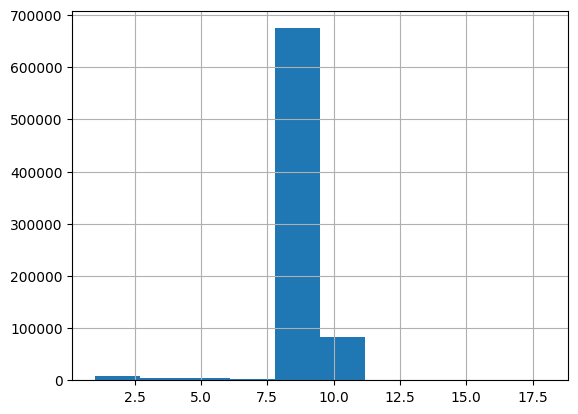

In [19]:
new_con.producto.value_counts().hist();

In [20]:
df_c = pd.concat([df, new_con], ignore_index=True)

In [21]:
df_c.drop(columns=['lv_cons_id_cons', 'fecha', 'MES_CONSUMO'], inplace=True)

In [22]:
df_c['fecha'] = pd.to_datetime(df_c[['ano', 'mes']].rename(columns={'ano': 'year', 'mes': 'month'}).assign(day=1))

In [23]:
df_c.sort_values(['producto', 'fecha'], inplace=True)
df_c.reset_index(drop=True, inplace=True)
df_c

,ano,mes,consumo,producto,localidad,barrio,tipo_producto,categoria,subcategoria,fecha
0,2023,12,170.0,2,76001.0,102.0,6140.0,1.0,1.0,2023-12-01
1,2024,1,170.0,2,76001.0,102.0,6140.0,1.0,1.0,2024-01-01
2,2024,2,170.0,2,76001.0,102.0,6140.0,1.0,1.0,2024-02-01
3,2024,3,170.0,2,76001.0,102.0,6140.0,1.0,1.0,2024-03-01
4,2024,4,170.0,2,76001.0,102.0,6140.0,1.0,1.0,2024-04-01
...,...,...,...,...,...,...,...,...,...,...
16006101,2025,6,0.0,16037818,76001.0,1599.0,6140.0,1.0,2.0,2025-06-01
16006102,2025,5,0.0,16037821,76001.0,1599.0,6140.0,1.0,2.0,2025-05-01
16006103,2025,6,0.0,16037821,76001.0,1599.0,6140.0,1.0,2.0,2025-06-01
16006104,2025,5,0.0,16038136,76001.0,1598.0,6140.0,1.0,1.0,2025-05-01


In [24]:
df_c.drop_duplicates(inplace=True)
df_c.shape

(16006106, 10)

In [25]:
# Identify products without complete time series
# Group by product and count the number of records
producto_counts = df_c.groupby('producto').size()

# Get the expected number of months in the dataset
expected_months = df_c.groupby('producto').size().max()

# Find products with incomplete time series
incomplete_products = producto_counts[producto_counts < expected_months].index.tolist()

print(f"Total unique products: {df_c['producto'].nunique()}")
print(f"Expected months per product: {expected_months}")
print(f"Products with incomplete time series: {len(incomplete_products)}")
print(f"\nFirst 10 incomplete product IDs: {incomplete_products[:10]}")

# Show details of incomplete products
incomplete_df = df_c[df_c['producto'].isin(incomplete_products)].groupby('producto').size().reset_index(name='count')
print(f"\nDistribution of records for incomplete products:")
print(incomplete_df['count'].value_counts().sort_index())

Total unique products: 906373
Expected months per product: 28
Products with incomplete time series: 906372

First 10 incomplete product IDs: [2, 6, 11, 15, 19, 24, 28, 33, 37, 41]

Distribution of records for incomplete products:
count
2       2677
3       1517
10    123872
11      5349
12      1954
13      1940
14      3144
15      2305
16      2962
17      2332
18      8639
19    665867
20     82936
21       751
22        94
23        17
24        11
25         1
26         3
27         1
Name: count, dtype: int64


In [26]:
df_c.producto.value_counts()

producto
2436255     28
13032178    27
1526555     26
1946200     26
1215703     26
            ..
16037356     2
16037695     2
16037818     2
16037821     2
16033430     2
Name: count, Length: 906373, dtype: int64

In [27]:
df_c[df_c.producto == 13032178]

,ano,mes,consumo,producto,localidad,barrio,tipo_producto,categoria,subcategoria,fecha
12259660,2023,12,0.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2023-12-01
12259661,2023,12,26641.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2023-12-01
12259662,2024,1,0.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-01-01
12259663,2024,1,9390.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-01-01
12259664,2024,2,9390.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-02-01
12259665,2024,2,0.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-02-01
12259666,2024,3,9570.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-03-01
12259667,2024,3,0.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-03-01
12259668,2024,4,0.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-04-01
12259669,2024,4,8850.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-04-01


In [30]:
keys = ["producto", "fecha"]   # o ["producto","ano","mes"]
c = df_c["consumo"]

score = (c.notna().astype(np.int8) + c.fillna(0).gt(0).astype(np.int8) * 2)

# idxmax del score por grupo (sin sort)
idx = score.groupby([df_c[k] for k in keys], sort=False).idxmax()

# filtra (opcional: conserva el orden original)
df_dedup = df_c.loc[idx].sort_index()

In [32]:
df_dedup.shape

(15786779, 10)

In [31]:
df_dedup[df_dedup.producto == 13032178]

,ano,mes,consumo,producto,localidad,barrio,tipo_producto,categoria,subcategoria,fecha
12259661,2023,12,26641.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2023-12-01
12259663,2024,1,9390.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-01-01
12259664,2024,2,9390.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-02-01
12259666,2024,3,9570.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-03-01
12259669,2024,4,8850.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-04-01
12259671,2024,5,8730.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-05-01
12259672,2024,6,8850.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-06-01
12259674,2024,7,9810.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-07-01
12259675,2024,8,9600.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-08-01
12259677,2024,9,9600.0,13032178,76001.0,1784.0,6140.0,2.0,4.0,2024-09-01


In [33]:
# Identify products without complete time series
# Group by product and count the number of records
producto_counts = df_dedup.groupby('producto').size()

# Get the expected number of months in the dataset
expected_months = df_dedup.groupby('producto').size().max()

# Find products with incomplete time series
incomplete_products = producto_counts[producto_counts < expected_months].index.tolist()

print(f"Total unique products: {df_dedup['producto'].nunique()}")
print(f"Expected months per product: {expected_months}")
print(f"Products with incomplete time series: {len(incomplete_products)}")
print(f"\nFirst 10 incomplete product IDs: {incomplete_products[:10]}")

# Show details of incomplete products
incomplete_df = df_dedup[df_dedup['producto'].isin(incomplete_products)].groupby('producto').size().reset_index(name='count')
print(f"\nDistribution of records for incomplete products:")
print(incomplete_df['count'].value_counts().sort_index())

Total unique products: 906373
Expected months per product: 19
Products with incomplete time series: 258564

First 10 incomplete product IDs: [2, 6, 11, 15, 19, 28, 33, 53, 61, 70]

Distribution of records for incomplete products:
count
2       2677
3       1517
10    123872
11      5504
12      1924
13      2024
14      3194
15      2425
16      2871
17     33196
18     79360
Name: count, dtype: int64


In [37]:
import pandas as pd

df_dedup["producto"] = df_dedup["producto"].astype("category")

# 1) índice mensual (mes)
df = df_dedup.copy()
df["period"] = pd.PeriodIndex(year=df["ano"].astype("int16"),
                              month=df["mes"].astype("int8"),
                              freq="M")

# 2) rango completo de meses
all_periods = pd.period_range("2023-12", "2025-06", freq="M")

# 3) índice completo productos × meses
full_index = pd.MultiIndex.from_product(
    [df["producto"].cat.categories, all_periods],
    names=["producto", "period"]
)

# 4) reindex -> crea filas faltantes con NaN
df_full = (df.set_index(["producto", "period"])
             .reindex(full_index)
             .reset_index())

# 5) reconstruye ano/mes (y opcional fecha)
df_full["ano"] = df_full["period"].dt.year.astype("int16")
df_full["mes"] = df_full["period"].dt.month.astype("int8")
df_full["fecha"] = df_full["period"].dt.to_timestamp()  # primer día del mes (opcional)

df_full = df_full.drop(columns=["period"])


/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_22174/417603794.py:7: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  df["period"] = pd.PeriodIndex(year=df["ano"].astype("int16"),


In [38]:
df_full.producto.value_counts()

producto
16038136    19
2           19
6           19
11          19
15          19
            ..
37          19
41          19
45          19
49          19
53          19
Name: count, Length: 906373, dtype: int64

In [39]:
df_full

,producto,ano,mes,consumo,localidad,barrio,tipo_producto,categoria,subcategoria,fecha
0,2,2023,12,170.0,76001.0,102.0,6140.0,1.0,1.0,2023-12-01
1,2,2024,1,170.0,76001.0,102.0,6140.0,1.0,1.0,2024-01-01
2,2,2024,2,170.0,76001.0,102.0,6140.0,1.0,1.0,2024-02-01
3,2,2024,3,170.0,76001.0,102.0,6140.0,1.0,1.0,2024-03-01
4,2,2024,4,170.0,76001.0,102.0,6140.0,1.0,1.0,2024-04-01
...,...,...,...,...,...,...,...,...,...,...
17221082,16038136,2025,2,NaN,NaN,NaN,NaN,NaN,NaN,2025-02-01
17221083,16038136,2025,3,NaN,NaN,NaN,NaN,NaN,NaN,2025-03-01
17221084,16038136,2025,4,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-01
17221085,16038136,2025,5,0.0,76001.0,1598.0,6140.0,1.0,1.0,2025-05-01


In [41]:
PATH = '/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/datos_procesados/'
df_full.to_parquet(PATH + "consumo_011223_01062025.parquet", engine="pyarrow", compression="snappy", index=False)


In [44]:
caracteristicas[~caracteristicas.producto.isin(new_con.producto.unique())]

,producto,localidad,barrio,tipo_producto,categoria,subcategoria
140,61,76001.0,102.0,6140.0,1.0,1.0
200,90,76001.0,102.0,6140.0,1.0,1.0
210,95,76001.0,102.0,6140.0,1.0,1.0
730,331,76001.0,101.0,6140.0,1.0,2.0
770,348,76001.0,101.0,6140.0,1.0,2.0
...,...,...,...,...,...,...
9031685,16037356,76001.0,1598.0,6140.0,1.0,2.0
9031687,16037695,76001.0,1596.0,6140.0,1.0,3.0
9031689,16037818,76001.0,1599.0,6140.0,1.0,2.0
9031691,16037821,76001.0,1599.0,6140.0,1.0,2.0


In [45]:
caracteristicas.shape

(906373, 6)

## Bases para DASHBOARD

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet('/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/datos_procesados/consumo_011223_01062025_filtrado.parquet')
df.head()

,producto,ano,mes,consumo,localidad,barrio,tipo_producto,categoria,subcategoria,fecha,CLIENTE_ID
0,41,2023,12,165.0,76001.0,102.0,6140.0,1.0,1.0,2023-12-01,41
1,41,2024,1,170.0,76001.0,102.0,6140.0,1.0,1.0,2024-01-01,41
2,41,2024,2,165.0,76001.0,102.0,6140.0,1.0,1.0,2024-02-01,41
3,41,2024,3,156.0,76001.0,102.0,6140.0,1.0,1.0,2024-03-01,41
4,41,2024,4,182.0,76001.0,102.0,6140.0,1.0,1.0,2024-04-01,41


In [3]:
col_comercial = [
    "lv_datcom_id_datcom",
    "producto",
    "contrato",
    "nombre_de_usuario",
    "direccion_oficial",
    "direccion_de_instalacion",
    "identificacion_direccion",
    "fecha_de_instalacion",
    "tipo_producto",
    "categoria",
    "subcategoria",
    "localidad",
    "barrio",
    "plan_de_facturacion",
    "estado_de_corte",
    "cuentas_energia",
    "saldo_energia",
    "creacion_producto",
    "retiro_de_producto",
    "ciclo",
    "nombre_usuario_oficial",
    "direccion",
    "cuentas_total",
    "saldo_total",
    "fecha_cargue"
]

In [4]:
df_com = pd.read_csv('../../data/EMCALI/lv_data_comercial.csv')
df_com.columns = col_comercial

/var/folders/t9/n67k3lts6wl76ntfbg_ntw3w0000gn/T/ipykernel_833/3661465880.py:1: DtypeWarning: Columns (0,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df_com = pd.read_csv('../../data/EMCALI/lv_data_comercial.csv')


In [26]:
df_com_keep = df_com[['producto', 'direccion_oficial', 'direccion_de_instalacion', 
                      'fecha_de_instalacion', 'tipo_producto', 'categoria', "subcategoria",
                      "localidad", "barrio", 'direccion']].copy()

df_com_keep = df_com_keep[~df_com_keep.producto.isna()]

In [27]:
df_com_keep.duplicated().sum()

0

In [28]:
df_com_keep.drop(columns=['direccion', 'fecha_de_instalacion'], inplace=True)

In [22]:
df_com_keep.sort_values(['producto'], inplace=True)
df_com_keep.reset_index(drop=True, inplace=True)

In [32]:
df_com_keep.to_csv('/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/dashboards/info_usuarios.csv', index=False)

In [34]:
df[['producto', 'ano', 'mes', 'consumo']].to_csv('/Users/catalinabernal/Desktop/Quantil/DISICO/DISICO-Anomalias-Energia/data/EMCALI/dashboards/info_consumo.csv', index=False)